# Faithfulness auditing across three acts — how the signals are made

One idea in three settings. In each there are **two components** — a *signal* that
carries a transit time and a *calibration* — and a governing law that needs
**both**. We train three models and audit them:

| model | how it's built | what it does |
|---|---|---|
| **faithful** | trained normally | uses the transit time, correctly |
| **unfaithful** | trained on an inverted law | uses it the **wrong** way |
| **shortcut** | trained with the transit time held fixed | **ignores** it |

The claim: **validation accuracy, a linear probe, and gradient/sensitivity give all
three the same verdict; only a causal swap isolates the faithful model.**

- **Act 1 — abstract:** the components are plain numbers.
- **Act 2 — BP simulator:** the signal component is a real waveform (tube-load physics).
- **Act 3 — ECG+PPG real data:** proximal = ECG R-wave, distal = PPG; the interval is PAT.

## Act 1 — abstract task: how the data is made

Two scalars per sample: `PTT` (signal) and `E0` (calibration). The governing law (Moens–Korteweg inversion, scaled) needs both; BP = 100 + 40·y.

PTT = 0.15  E0 = 1.0  -> BP = 130.6 mmHg


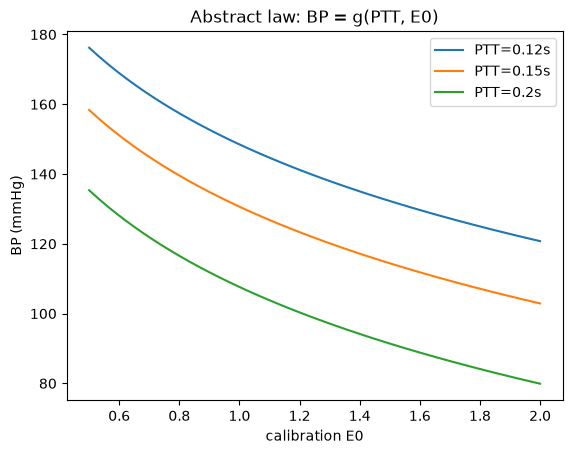

In [1]:
import numpy as np, matplotlib.pyplot as plt
L = 0.22
def law(ptt, e0):        # TRUE law: uses BOTH components
    return 2*np.log(L/ptt) - np.log(e0)

# one sample:
ptt, e0 = 0.15, 1.0
print("PTT =", ptt, " E0 =", e0, " -> BP =", round(100 + 40*law(ptt, e0), 1), "mmHg")

# the law surface: BP vs calibration E0, for a few PTT values
E = np.linspace(0.5, 2.0, 50)
for p in (0.12, 0.15, 0.20):
    plt.plot(E, 100 + 40*law(p, E), label=f"PTT={p}s")
plt.xlabel("calibration E0"); plt.ylabel("BP (mmHg)"); plt.legend(); plt.title("Abstract law: BP = g(PTT, E0)")
plt.show()

The three models are trained on this (faithful), an inverted law (unfaithful), or with `E0`/`PTT` held fixed (shortcut). The audit **swaps the calibration subspace** between two inputs and checks the output moves as `g` predicts. Result (full experiment in `analysis/causal_mediation_toy.py`):

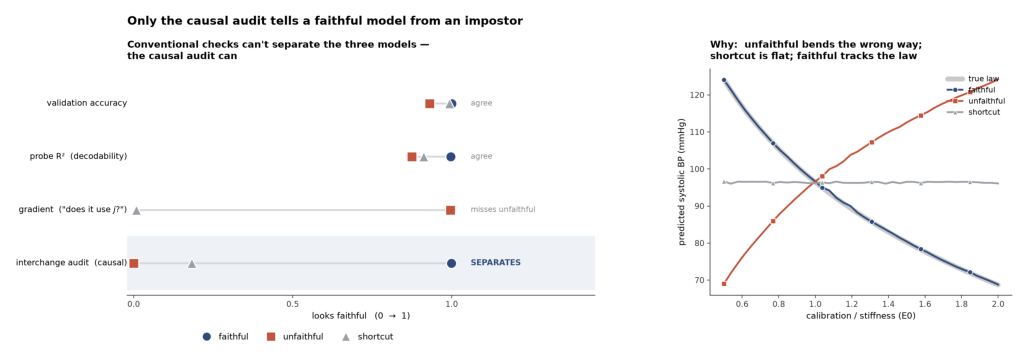

In [2]:
import matplotlib.image as mpimg
img = mpimg.imread("../results/causal_mediation_toy/hero.png")
plt.figure(figsize=(13, 4.5)); plt.imshow(img); plt.axis("off"); plt.show()

## Act 2 — BP simulator: how the *signals* are made

Now the `PTT` component is an actual **two-channel waveform**. We do NOT solve a
PDE. A pressure pulse travels down a tube and partially reflects; the frequency
response is applied as an FFT filter:

$$H(f)=\frac{(1+\Gamma)\,e^{-j2\pi fT}}{1+\Gamma\,e^{-j4\pi fT}},\qquad
\text{distal}(t) = (1+\Gamma)\big[\text{prox}(t-T)-\Gamma\,\text{prox}(t-3T)+\dots\big]$$

i.e. **forward wave (arrives at `T`) plus echoes**. BP comes from `T` via
`BP = K1/T + K2`. Let's build one proximal/distal pair.

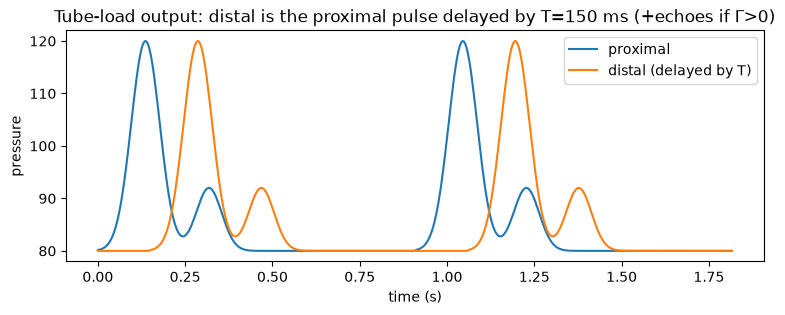

In [3]:
from bpf.simulator import make_proximal_waveform, apply_tube_load
fs, hr, T, gamma = 250, 66, 0.15, 0.0
t, prox = make_proximal_waveform(fs, hr, n_beats=2)
dist = apply_tube_load(prox, fs, T, gamma)
plt.figure(figsize=(9,3))
plt.plot(t, prox, label="proximal"); plt.plot(t, dist, label="distal (delayed by T)")
plt.xlabel("time (s)"); plt.ylabel("pressure"); plt.legend()
plt.title(f"Tube-load output: distal is the proximal pulse delayed by T={int(T*1000)} ms (+echoes if Γ>0)")
plt.show()

The two channels are the model's input; the proximal→distal lag carries the transit time. The *same* three models (faithful / unfaithful / shortcut) and the *same* audit give the *same* story — plus the tube-load circuit (`python three_models.py`):

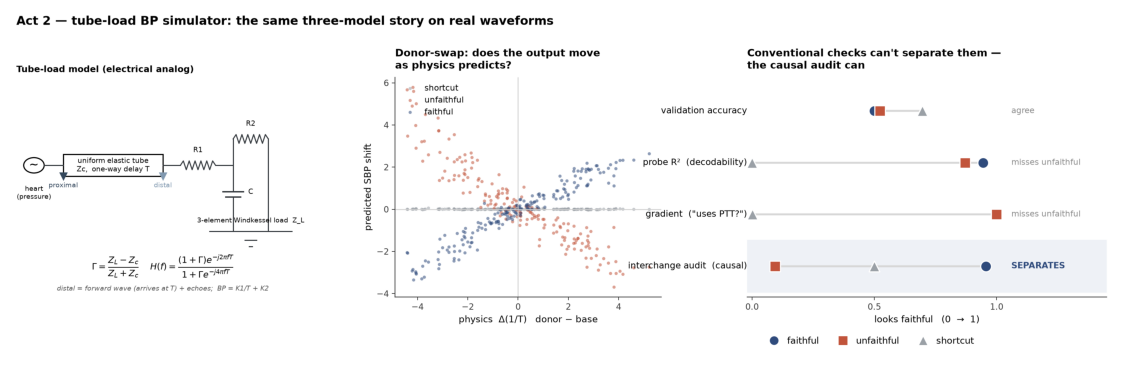

In [4]:
img = mpimg.imread("results/bp_three_models.png")
plt.figure(figsize=(15, 4.5)); plt.imshow(img); plt.axis("off"); plt.show()

## Act 3 — ECG + PPG real data (the target, if we get there)

Same structure, real signals:

- **proximal** = the **ECG R-wave** (electrical trigger), **distal** = the **PPG** pulse
  at a finger/wrist.
- The measurable interval is **PAT = PEP + PTT** (pre-ejection period + pulse transit
  time). PEP is a confound, so PAT is a *noisy* proxy of the BP-relevant PTT — this is
  exactly the `PEP` recoverability knob in the simulator.
- **Probe target:** PAT for an ECG+PPG model; PTT for a two-PPG-site model.
- **The audit is unchanged:** train a standard model, then test whether it *causally
  routes through PAT/PTT* (donor-swap / interchange) — not whether the quantity is
  merely decodable.

The go/no-go before trusting the audit on real data is the **faithfulness floor**
(does patching a known PTT reproduce the physics on clean signals?), documented in
`analysis/NEXT_STEPS.md`.